# AdaBoostRegressor Regression Notebook


## 1. Introduction
 
**AdaBoost Regressor** is an ensemble machine learning algorithm that builds a strong regressor by combining multiple weak regressors (typically decision trees).  

 - **ML Problem Type:** Regression (predicting continuous values)  
 - **Applications:**  
     - Predicting house prices  
     - Forecasting sales or stock prices  
     - Energy consumption prediction  
 - **Why Useful:**  
     - Reduces bias  
     - Improves model accuracy by focusing on difficult-to-predict examples  


**Importing Libraries**

In [1]:
import pandas as pd  # Data manipulation
import numpy as np   # Numerical operations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns  # Advanced visualization

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

import shap  # Model interpretability
import joblib  # Save/load models

**Load dataset**

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

In [4]:
# Dataset shape and first few rows
print("Shape of features:", X.shape)
print("Shape of target:", y.shape)

Shape of features: (20640, 8)
Shape of target: (20640,)


In [5]:
display(X.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
print("\nTarget shape:", y.shape)


Target shape: (20640,)


In [7]:
print("\nDataset description:\n", data.DESCR)


Dataset description:
 .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. censu

**Exploratory Data Analysis (EDA)**

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [9]:
print("Data types:\n", X.dtypes)

Data types:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object


In [10]:
print("\nMissing values:\n", X.isnull().sum())


Missing values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [11]:
print("\nStatistical summary:\n", X.describe())


Statistical summary:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.42

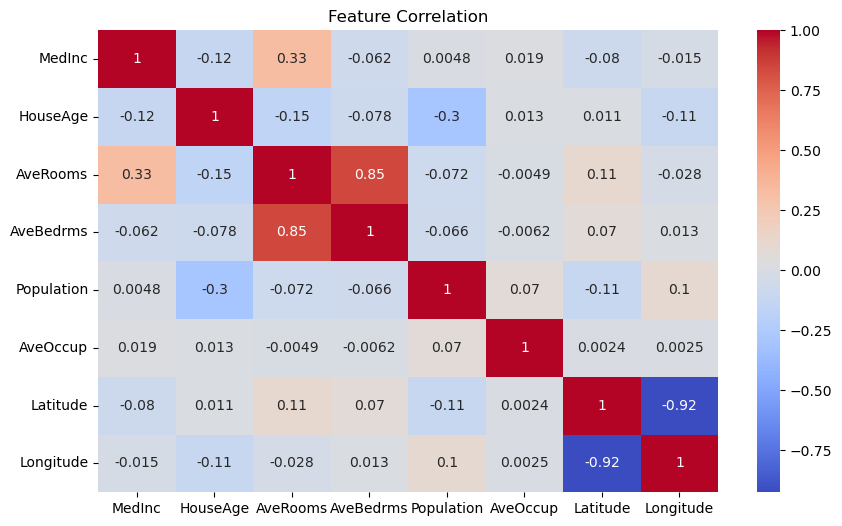

In [12]:
# Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

**Train-Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (16512, 8)
Test set shape: (4128, 8)


**Train AdaBoost Model**

In [15]:
base_tree = DecisionTreeRegressor(max_depth=4)

model = AdaBoostRegressor(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                  learning_rate=0.1, n_estimators=100, random_state=42)

**Hyperparameter Tuning with GridSearchCV**

In [16]:
param_grid = {
    "n_estimators": [50,100,200],
    "learning_rate": [0.01,0.1,0.5],
    "estimator__max_depth": [2,3,4,5]
}

In [17]:
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)


In [18]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits


**Model Evaluation**

In [19]:
y_pred = best_model.predict(X_test)

In [20]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [21]:
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 0.42947745863206477
RMSE: 0.6553452972533371
MAE : 0.5105446003512955
R2  : 0.6722569321765501


**Feature Importance Visualization**

In [22]:
importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,MedInc,0.428142
5,AveOccup,0.147518
6,Latitude,0.143434
7,Longitude,0.141018
1,HouseAge,0.046922
2,AveRooms,0.045745
4,Population,0.023951
3,AveBedrms,0.023269


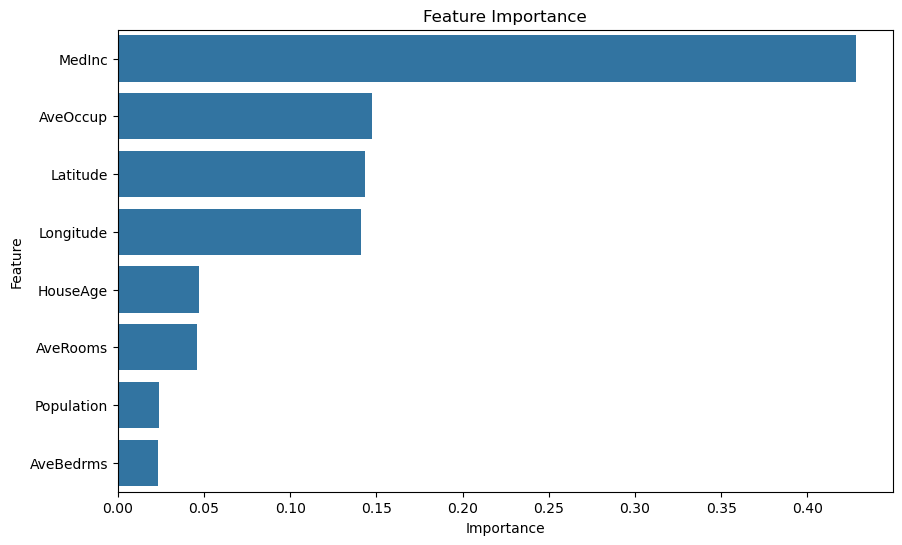

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

**Model Explainability using SHAP**

ExactExplainer explainer: 201it [01:32,  2.17it/s]                                                                     


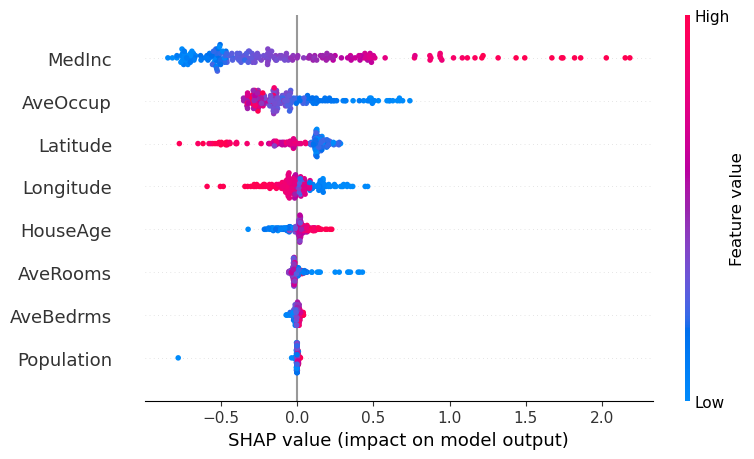

In [24]:
import shap

X_sample = X_train.sample(100)

explainer = shap.Explainer(best_model.predict, X_sample)
shap_values = explainer(X_test[:200])

shap.summary_plot(shap_values, X_test[:200])

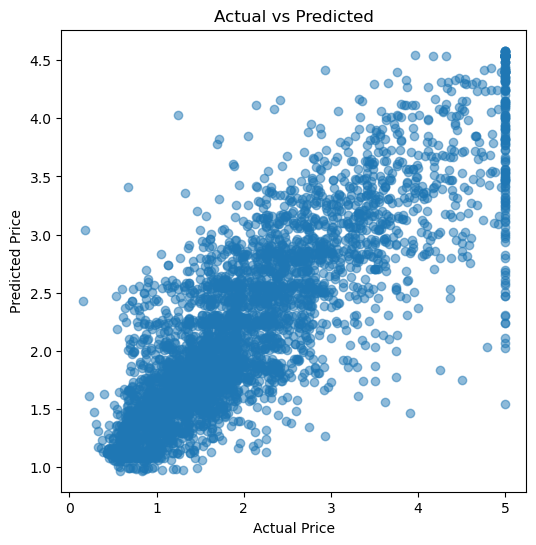

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

### Model Theory: AdaBoost Regressor


#### 1. Algorithm Overview:
- AdaBoost combines weak learners sequentially.
- Each new tree focuses more on instances with higher error.
- Final prediction is a weighted sum of all weak learners.

#### 2. Mathematical Intuition:
- Prediction: F(x) = sum(alpha_m * h_m(x))
- alpha_m is the weight based on the weak learner's performance.
- h_m(x) is the prediction from the m-th weak learner.

#### 3. When to Use:
- Regression tasks with moderate complexity.
- Problems where boosting can improve weak learners.

#### 4. Advantages:
- Reduces bias
- Handles complex relationships
- Less prone to overfitting than some other ensembles

#### 5. Disadvantages:
- Sensitive to noisy data and outliers
- Can be slow if many weak learners

#### 6. Important Hyperparameters:
- n_estimators: Number of weak learners
- learning_rate: Shrinkage factor for weak learners
- base_estimator parameters: e.g., max_depth

#### 7. Practical Tuning Tips:
- Start with shallow trees (max_depth 3-5)
- Adjust learning_rate with n_estimators (smaller learning rate -> more estimators)
- Monitor residuals to detect under/overfitting
